# 3D ガウシアン電荷ポテンシャルの低ランク近似

1D Tucker ノートブックの 3D 拡張。3D Coulomb カーネル $K(r) = 1/\sqrt{r^2+\varepsilon^2}$ について

1. $N^3 \times N^3$ 行列としての SVD 近似
2. 近距離/遠距離分離 (hard mask, smoothstep) + 遠距離 SVD
3. RPCA による $K = L + S$ 分解
4. $K$ を 6-way テンソルと見た Tucker 分解（3D 固有の多重線形構造）
5. 直接畳み込み vs CG poisson solver vs 解析解

を比較する。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

from src.utils.grid import build_xyz
from src.utils.metrics import l2_error
from src.decomposition.tucker import perform_tucker, reconstruct, perform_tucker_rpca
from src.decomposition.rpca import randomized_rpca
from src.potential.poisson_solver import poisson_solve
from src.potential.charge_potential import v_analytic_gaussian

## グリッドと 3D Coulomb カーネル

$K_{ab} = 1 / \sqrt{|x_a - x_b|^2 + \varepsilon^2}$。 $N=13$ で $K$ は $2197 \times 2197$。

In [5]:
N = 15
L = 6.0
alpha = 1.0

dx = L / N
eps = dx / 2
xyz = build_xyz(N, L)
R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

grid_pts = np.stack([xyz[0].ravel(), xyz[1].ravel(), xyz[2].ravel()], axis=1)

diff = grid_pts[:, None, :] - grid_pts[None, :, :]
dists = np.sqrt((diff**2).sum(-1))
K = 1.0 / np.sqrt((diff**2).sum(-1) + eps**2)

rho_grid = np.exp(-alpha * R**2)
rho_flat = rho_grid.ravel()

V_flat = K @ rho_flat * dx**3
V_grid = V_flat.reshape(N, N, N)

print(f"K.shape = {K.shape}, mem = {K.nbytes/1e6:.1f} MB")
print(f"V max/min = {V_grid.max():.4f} / {V_grid.min():.4f}")

K.shape = (3375, 3375), mem = 91.1 MB
V max/min = 5.9369 / 1.1471


## 行列 SVD によるランク $r$ 近似

テンソルを行列化し、1Dと同じような手法で試してみる

top-10 singular values: [1172.216  362.723  362.723  362.723  237.59   237.59   237.59   222.661
  206.152  206.152]


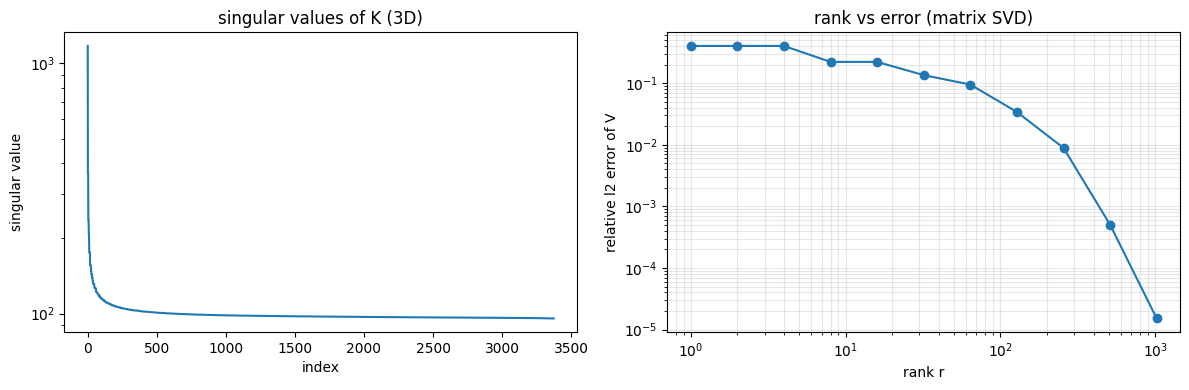

In [54]:
U, s, Vt = np.linalg.svd(K)
print("top-10 singular values:", s[:10].round(3))

ranks = [r for r in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] if r < N**3]
errors_svd = []
for r in ranks:
    K_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    V_r = K_r @ rho_flat * dx**3
    errors_svd.append(np.linalg.norm(V_r - V_flat) / np.linalg.norm(V_flat))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(np.arange(len(s)), s)
axes[0].set_xlabel('index')
axes[0].set_ylabel('singular value')
axes[0].set_title('singular values of K (3D)')

axes[1].loglog(ranks, errors_svd, 'o-')
axes[1].set_xlabel('rank r')
axes[1].set_ylabel('relative l2 error of V')
axes[1].set_title('rank vs error (matrix SVD)')
axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 近距離/遠距離 hybrid: hard mask

対角近傍の特異性が SVD の収束を遅らせるので、近距離は直接、遠距離だけ低ランクで扱う。

near density = 0.0085, threshold = 0.800


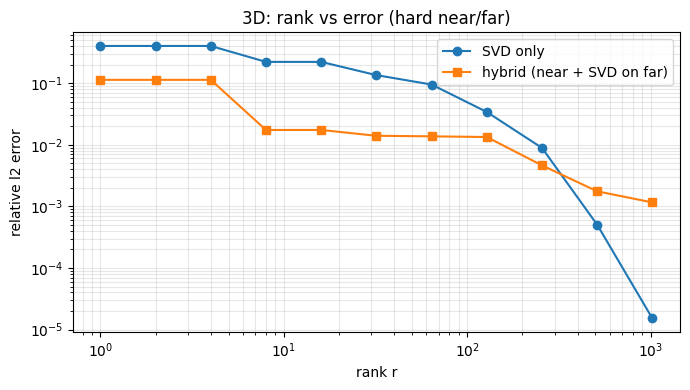

In [55]:
n_neighbors = 2  # 「2 grid spacing 以内を near」とする
threshold = n_neighbors * dx + 1e-9   # 数値の安全マージン
near_mask = dists <= threshold
K_near = K * near_mask
K_far = K * ~near_mask

print(f"near density = {near_mask.mean():.4f}, threshold = {threshold:.3f}")

U_far, s_far, Vt_far = np.linalg.svd(K_far)

errors_hybrid = []
for r in ranks:
    K_far_r = (U_far[:, :r] * s_far[:r]) @ Vt_far[:r, :]
    V_h = (K_near + K_far_r) @ rho_flat * dx**3
    errors_hybrid.append(np.linalg.norm(V_h - V_flat)/np.linalg.norm(V_flat))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ranks, errors_svd, 'o-', label='SVD only')
ax.loglog(ranks, errors_hybrid, 's-', label='hybrid (near + SVD on far)')
ax.set_xlabel('rank r')
ax.set_ylabel('relative l2 error')
ax.set_title('3D: rank vs error (hard near/far)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

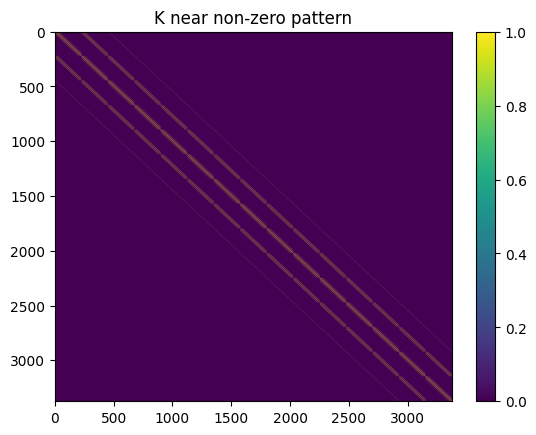

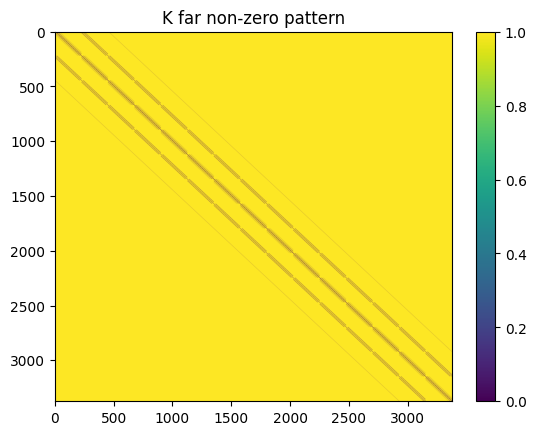

In [56]:
plt.imshow(np.abs(K_near) > 1e-6, aspect='auto')
plt.title("K near non-zero pattern")
plt.colorbar()
plt.show()
plt.imshow(np.abs(K_far) > 1e-6, aspect='auto')
plt.title("K far non-zero pattern")
plt.colorbar()
plt.show()

### smoothstep 窓による分離

hard mask は不連続性が遠距離成分の高周波成分を生むため、$C^1$ 連続な smoothstep 窓で分離。

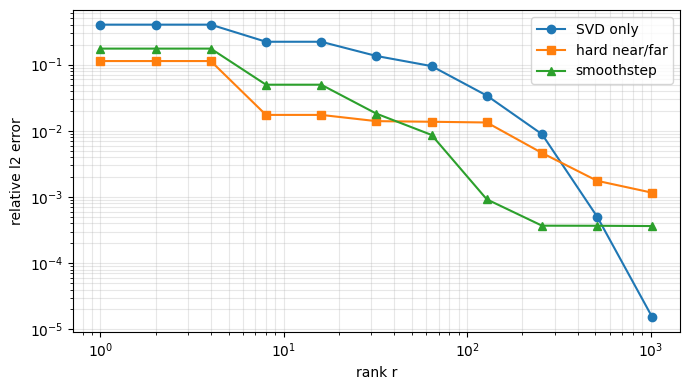

top-10 far singular values (smooth): [1060.6281  251.3827  251.3827  251.3827  126.5278  126.5278  126.5278
  111.6645   95.2609   95.2609]


In [57]:
def smoothstep(u, threshold):
    t = np.clip(np.abs(u) / threshold, 0, 1)
    return 1 - 3 * t**2 + 2 * t**3

w = smoothstep(dists, threshold)
K_near_s = K * w
K_far_s = K * (1 - w)

U_fs, s_fs, Vt_fs = np.linalg.svd(K_far_s)

errors_smooth = []
for r in ranks:
    K_far_r = (U_fs[:, :r] * s_fs[:r]) @ Vt_fs[:r, :]
    V_h = (K_near_s + K_far_r) @ rho_flat * dx**3
    errors_smooth.append(np.linalg.norm(V_h - V_flat)/np.linalg.norm(V_flat))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ranks, errors_svd, 'o-', label='SVD only')
ax.loglog(ranks, errors_hybrid, 's-', label='hard near/far')
ax.loglog(ranks, errors_smooth, '^-', label='smoothstep')
ax.set_xlabel('rank r')
ax.set_ylabel('relative l2 error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print('top-10 far singular values (smooth):', s_fs[:10].round(4))

### Randomized RPCA による $K = L + S$ 分解

1D 同様、近傍の集中部分を $S$ にスパースに押し出して、$L$ を綺麗な低ランク化候補にする。

In [58]:
print('randomized RPCA running...')
L_rpca, S_rpca = randomized_rpca(K, rank=500, max_iter=10000, tol=1e-6, verbose=True)

rank_L = (np.linalg.svd(L_rpca, compute_uv=False) > 1e-6).sum()
print(f"L 実効ランク : {rank_L}")
print(f"S 非ゼロ率   : {(np.abs(S_rpca) > 1e-6).mean():.4f}")

U_L, s_L, Vt_L = np.linalg.svd(L_rpca)

errors_rpca = []
for r in ranks:
    if r > U_L.shape[1]:
        errors_rpca.append(np.nan)
        continue
    L_r = (U_L[:, :r] * s_L[:r]) @ Vt_L[:r, :]
    V_h = (L_r + S_rpca) @ rho_flat * dx**3
    errors_rpca.append(np.linalg.norm(V_h - V_flat)/np.linalg.norm(V_flat))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ranks, errors_svd, 'o-', label='SVD only')
ax.loglog(ranks, errors_hybrid, 's-', label='hard near/far')
ax.loglog(ranks, errors_smooth, '^-', label='smoothstep')
ax.loglog(ranks, errors_rpca, 'd-', label='randomized RPCA')
ax.set_xlabel('rank r')
ax.set_ylabel('relative l2 error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

randomized RPCA running...


KeyboardInterrupt: 

In [ ]:
print(sum(L_rpca))

[459.87235415 484.77146119 506.62075988 ... 506.62062895 484.77157722
 459.87240469]


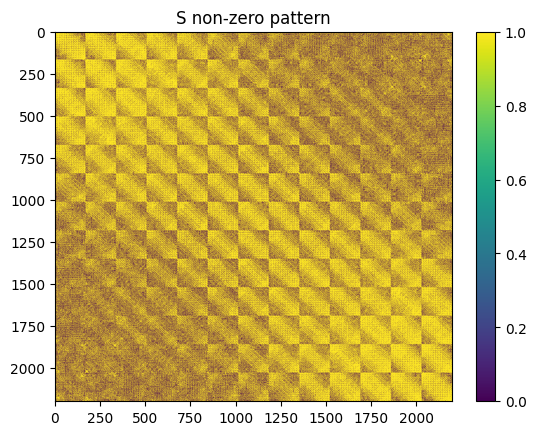

In [ ]:
plt.imshow(np.abs(S_rpca)>1e-6, aspect='auto')
plt.title("S non-zero pattern")
plt.colorbar()
plt.show()

S 非ゼロ率 = 0.7003
S Frobenius / K Frobenius = 0.7288


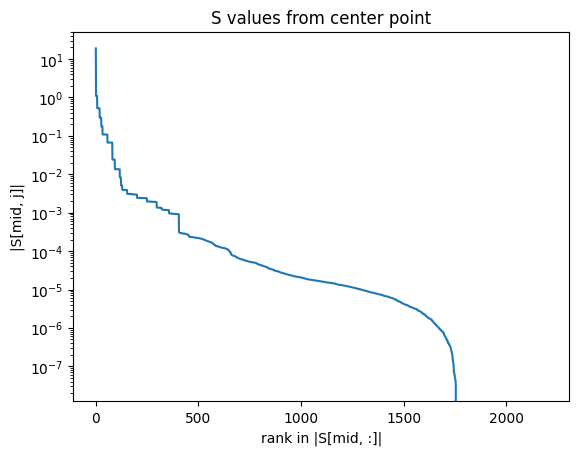

In [ ]:
print(f"S 非ゼロ率 = {(np.abs(S_rpca) > 1e-6).mean():.4f}")
print(f"S Frobenius / K Frobenius = {np.linalg.norm(S_rpca)/np.linalg.norm(K):.4f}")

# 中心点 (mid_idx) から各点への S を 3D 距離でソートしてプロット
mid_idx = N**3 // 2
plt.semilogy(np.sort(np.abs(S_rpca[mid_idx, :]))[::-1])
plt.xlabel('rank in |S[mid, :]|')
plt.ylabel('|S[mid, j]|')
plt.title('S values from center point')
plt.show()


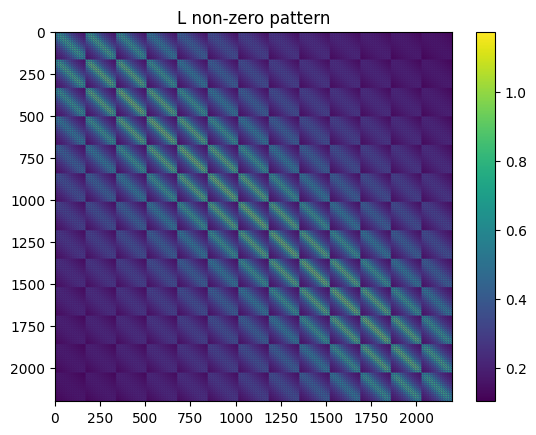

In [ ]:
plt.imshow(np.abs(L_rpca), aspect='auto')
plt.title("L non-zero pattern")
plt.colorbar()
plt.show()

各閾値で `S_thr = np.where(|S| > thr, S, 0)` を作って `(L_r + S_thr) ρ` の誤差を比較。
閾値を上げる → S 非ゼロ率減 → ストレージ減るが精度も落ちるトレードオフが見える。

C:\Users\masah\AppData\Local\Temp\ipykernel_20260\3846349297.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')


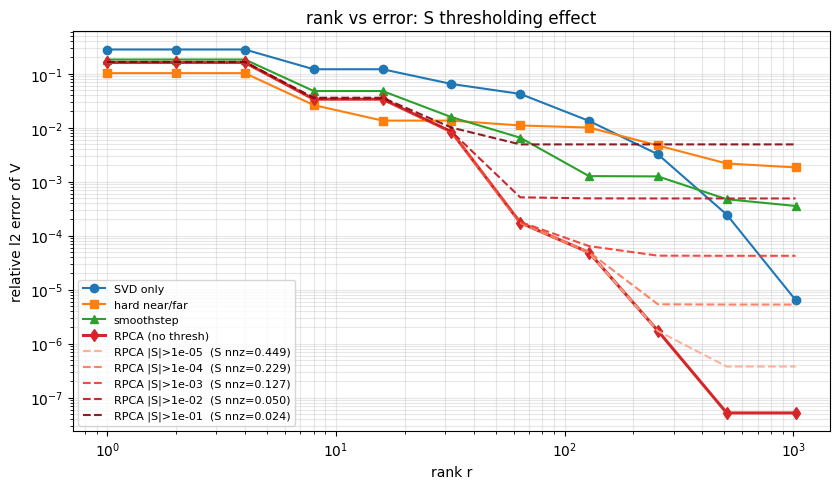

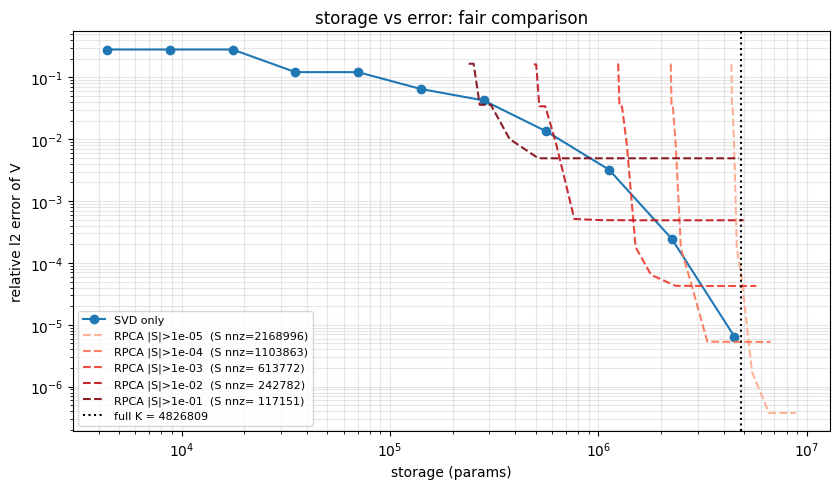

In [ ]:
thresholds_S = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
errors_rpca_thr = {thr: [] for thr in thresholds_S}
nnz_rates = {}

for thr in thresholds_S:
    S_thr = np.where(np.abs(S_rpca) > thr, S_rpca, 0)
    nnz_rates[thr] = (S_thr != 0).mean()
    for r in ranks:
        if r > U_L.shape[1]:
            errors_rpca_thr[thr].append(np.nan)
            continue
        L_r = (U_L[:, :r] * s_L[:r]) @ Vt_L[:r, :]
        V_h = (L_r + S_thr) @ rho_flat * dx**3
        errors_rpca_thr[thr].append(
            np.linalg.norm(V_h - V_flat) / np.linalg.norm(V_flat)
        )

# 共通の比較プロット
import matplotlib.cm as cm
cmap = cm.get_cmap('Reds')

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.loglog(ranks, errors_svd,    'o-', label='SVD only',          color='C0')
ax.loglog(ranks, errors_hybrid, 's-', label='hard near/far',     color='C1')
ax.loglog(ranks, errors_smooth, '^-', label='smoothstep',        color='C2')
ax.loglog(ranks, errors_rpca,   'd-', label='RPCA (no thresh)',  color='C3', lw=2.2)

n = len(thresholds_S)
for i, thr in enumerate(thresholds_S):
    color = cmap(0.30 + 0.65 * i / (n - 1))
    nnz = nnz_rates[thr]
    ax.loglog(
        ranks, errors_rpca_thr[thr], '--',
        color=color, alpha=0.9,
        label=f'RPCA |S|>{thr:.0e}  (S nnz={nnz:.3f})',
    )

ax.set_xlabel('rank r')
ax.set_ylabel('relative l2 error of V')
ax.set_title('rank vs error: S thresholding effect')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

# ストレージ vs 誤差（S は CSR で 2*nnz 要素相当として計上）
fig, ax = plt.subplots(figsize=(8.5, 5))
storages_svd_only = [2 * N**3 * r for r in ranks]
ax.loglog(storages_svd_only, errors_svd,    'o-', label='SVD only',         color='C0')

# RPCA 各しきい値: storage(L_r) + storage(S_thr)
for i, thr in enumerate(thresholds_S):
    color = cmap(0.30 + 0.65 * i / (n - 1))
    nnz = (np.abs(S_rpca) > thr).sum()
    storage_thr = [2 * N**3 * r + 2 * nnz for r in ranks]
    ax.loglog(
        storage_thr, errors_rpca_thr[thr], '--',
        color=color, alpha=0.9,
        label=f'RPCA |S|>{thr:.0e}  (S nnz={nnz:>7d})',
    )

ax.axvline(K.size, color='k', ls=':', label=f'full K = {K.size}')
ax.set_xlabel('storage (params)')
ax.set_ylabel('relative l2 error of V')
ax.set_title('storage vs error: fair comparison')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## $K$ を 6-way テンソルとみた Tucker 分解

$K \in \mathbb{R}^{N^3 \times N^3}$ を $K \in \mathbb{R}^{N \times N \times N \times N \times N \times N}$ と読み替える。

- 行列 SVD は $N^3$ 次元の 1 軸として扱う → 各軸の構造は無視
- Tucker 分解は 6 軸を独立に低ランク化 → 3D Coulomb の多重線形構造を exploit
- ストレージ: コア $r^6$ + 因子 $6 N r$ → $r$ が小さければ行列 SVD よりはるかにコンパクト

K_tensor.shape = (13, 13, 13, 13, 13, 13)
r= 1  V error=2.618e-01  storage=        79 (vs full 4826809, ratio=1.64e-05)
r= 2  V error=2.618e-01  storage=       220 (vs full 4826809, ratio=4.56e-05)
r= 3  V error=4.913e-02  storage=       963 (vs full 4826809, ratio=2.00e-04)
r= 4  V error=4.913e-02  storage=      4408 (vs full 4826809, ratio=9.13e-04)
r= 5  V error=1.969e-02  storage=     16015 (vs full 4826809, ratio=3.32e-03)
r= 6  V error=1.969e-02  storage=     47124 (vs full 4826809, ratio=9.76e-03)
r= 8  V error=5.582e-03  storage=    262768 (vs full 4826809, ratio=5.44e-02)
r=10  V error=3.229e-03  storage=   1000780 (vs full 4826809, ratio=2.07e-01)
r=12  V error=9.496e-04  storage=   2986920 (vs full 4826809, ratio=6.19e-01)


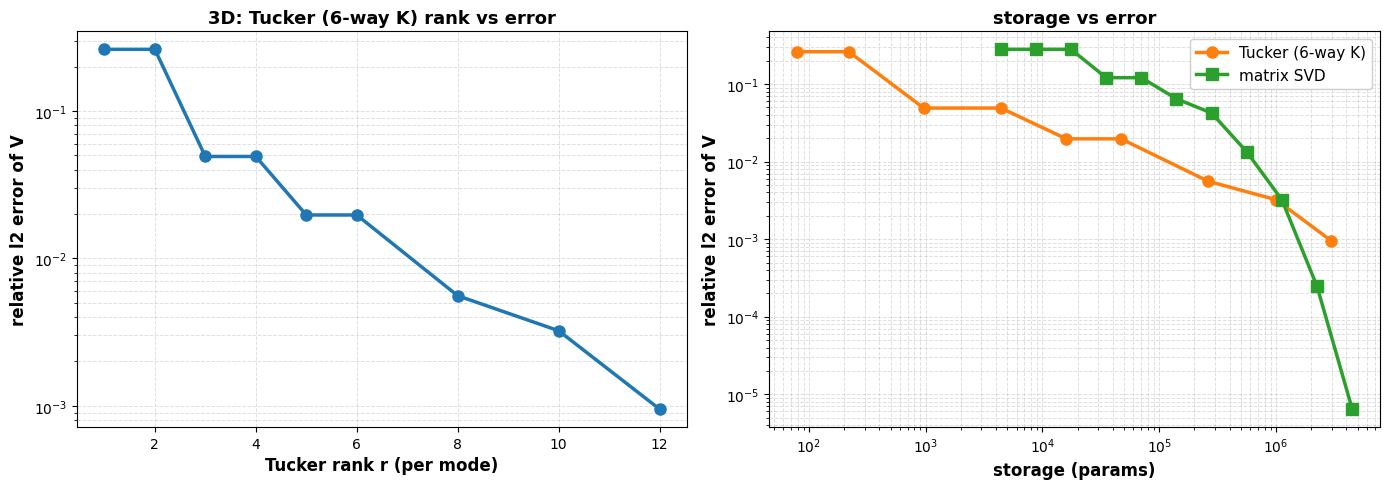

In [ ]:
K_tensor = K.reshape(N, N, N, N, N, N)
print(f'K_tensor.shape = {K_tensor.shape}')

ranks_t = [1, 2, 3, 4, 5, 6, 8, 10, 12]
errors_tucker = []
storages_tucker = []

for r in ranks_t:
    G, factors = perform_tucker(K_tensor, ranks=[r] * 6)
    K_approx_tensor = reconstruct(G, factors)
    K_approx = K_approx_tensor.reshape(N**3, N**3)

    V_t = K_approx @ rho_flat * dx**3
    err = np.linalg.norm(V_t - V_flat) / np.linalg.norm(V_flat)
    storage = G.size + sum(f.size for f in factors)

    errors_tucker.append(err)
    storages_tucker.append(storage)
    print(
        f"r={r:>2d}  V error={err:.3e}  storage={storage:>10d} "
        f"(vs full {K.size}, ratio={storage / K.size:.2e})"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左図：rank vs error
axes[0].semilogy(ranks_t, errors_tucker, 'o-', markersize=8, linewidth=2.5, color='C0')
axes[0].set_xlabel('Tucker rank r (per mode)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('relative l2 error of V', fontsize=12, fontweight='bold')
axes[0].set_title('3D: Tucker (6-way K) rank vs error', fontsize=13, fontweight='bold')
axes[0].grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)

# 右図：storage vs error
matrix_storages = [2 * N**3 * r for r in ranks]
axes[1].loglog(storages_tucker, errors_tucker, 'o-', markersize=8, linewidth=2.5, label='Tucker (6-way K)', color='C1')
axes[1].loglog(matrix_storages, errors_svd, 's-', markersize=8, linewidth=2.5, label='matrix SVD', color='C2')
axes[1].set_xlabel('storage (params)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('relative l2 error of V', fontsize=12, fontweight='bold')
axes[1].set_title('storage vs error', fontsize=13, fontweight='bold')
axes[1].grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
axes[1].legend(fontsize=11, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()

### ユーザー指定ランクでの 3 種類の Tucker 比較

全軸共通の `tucker_rank` を 1 つ指定して、Tucker の構成法を比較する:

1. **vanilla Tucker (HOSVD)**: 各 mode unfolding を直接 SVD して因子 $U_n$ を取る
2. **mode-wise RPCA Tucker**: 各 mode unfolding $M_n$ を RPCA で $L_n + S_n$ に分け、$L_n$ の SVD から因子 $U_n$ を取る
3. **full RPCA → Tucker(L) + S**: $K = L + S$ をまず行列 RPCA で分け、$L$ を 6-way テンソルとして Tucker、最後に $S$ を足し戻す

note: 各 mode unfolding は形状 $(N, N^5)$ で行方向が小さいため、低ランク + スパースの分離余地は限定的。それでも比較として掲載。

In [ ]:
# ----- ユーザー指定: 全軸共通の Tucker rank -----
tucker_rank = 4

# 既に L_rpca, S_rpca は rpca-cell で計算済み（K の行列 RPCA 結果を再利用）
L_tensor = L_rpca.reshape(N, N, N, N, N, N)

# 1. vanilla Tucker (HOSVD)
G_v, factors_v = perform_tucker(K_tensor, ranks=[tucker_rank] * 6)
K_v = reconstruct(G_v, factors_v).reshape(N**3, N**3)
V_v = K_v @ rho_flat * dx**3
err_v = np.linalg.norm(V_v - V_flat) / np.linalg.norm(V_flat)

"""
# 2. mode-wise RPCA Tucker
G_m, factors_m, sparse_modes = perform_tucker_rpca(
    K_tensor,
    ranks=[tucker_rank] * 6,
    rpca_rank=min(N - 1, max(tucker_rank * 2, 6)),
    max_iter=100,
    tol=1e-6,
)
K_m = reconstruct(G_m, factors_m).reshape(N**3, N**3)
V_m = K_m @ rho_flat * dx**3
err_m = np.linalg.norm(V_m - V_flat) / np.linalg.norm(V_flat)
"""

# 3. full RPCA → Tucker(L) + S
G_L, factors_L = perform_tucker(L_tensor, ranks=[tucker_rank] * 6)
K_L = reconstruct(G_L, factors_L).reshape(N**3, N**3)
V_LS = (K_L + S_rpca) @ rho_flat * dx**3
err_LS = np.linalg.norm(V_LS - V_flat) / np.linalg.norm(V_flat)

print(f"tucker_rank = {tucker_rank}")
print(f"  [1] vanilla Tucker(K)            : V error = {err_v:.3e}")
# print(f"  [2] mode-wise RPCA Tucker        : V error = {err_m:.3e}")
print(f"  [3] full RPCA → Tucker(L) + S    : V error = {err_LS:.3e}")
print()
"""
print("  各 mode の S_n 非ゼロ率:")
for n, s_n in enumerate(sparse_modes):
    print(f"    mode {n}: shape={s_n.shape}, nnz率={(np.abs(s_n) > 1e-6).mean():.4f}")
"""
print(f"  full RPCA の S 非ゼロ率: {(np.abs(S_rpca) > 1e-6).mean():.4f}")

tucker_rank = 4
  [1] vanilla Tucker(K)            : V error = 4.913e-02
  [3] full RPCA → Tucker(L) + S    : V error = 1.129e-02

  full RPCA の S 非ゼロ率: 0.7003


### ランク sweep での 3 手法の比較

rank |  vanilla Tucker |     Tucker(L)+S | Tucker(K-diag)+diag
   1 |       2.618e-01 |       1.492e-01 |          1.702e-01
   2 |       2.618e-01 |       1.492e-01 |          1.702e-01
   3 |       4.913e-02 |       1.129e-02 |          1.338e-02
   4 |       4.913e-02 |       1.129e-02 |          1.338e-02
   5 |       1.969e-02 |       3.405e-03 |          3.795e-03
   6 |       1.969e-02 |       3.405e-03 |          3.795e-03
   8 |       5.582e-03 |       1.200e-04 |          2.790e-03
  10 |       3.229e-03 |       7.734e-05 |          1.337e-03
  12 |       9.496e-04 |       6.498e-05 |          3.877e-04


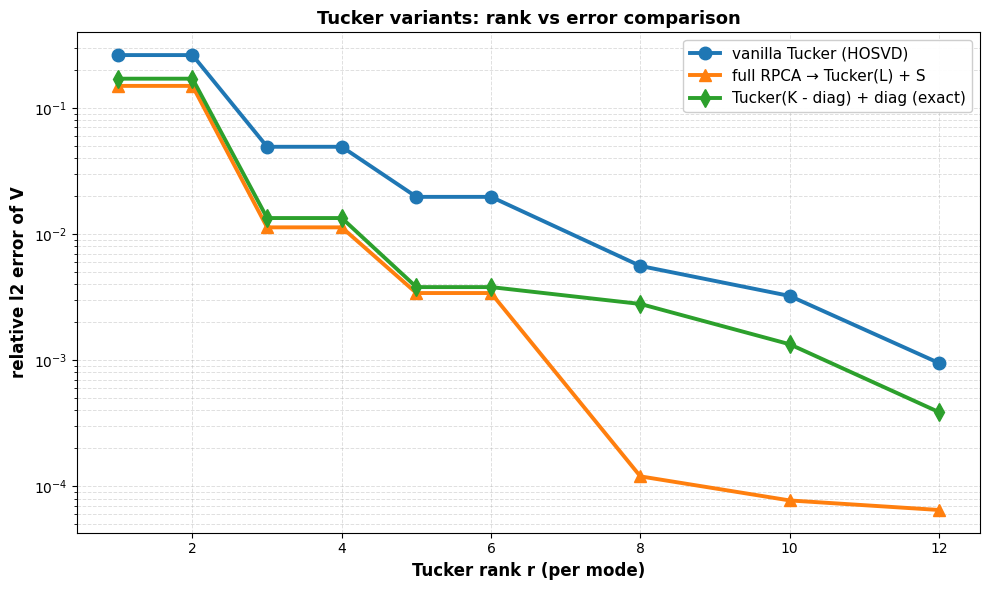

In [ ]:
# 対角を除いた K を 6-way Tucker、対角は別途厳密に保持

def smoothstep(u, threshold):
    t = np.clip(np.abs(u) / threshold, 0, 1)
    return 1 - 3 * t**2 + 2 * t**3

w = smoothstep(dists, threshold)
K_near_s = K * w
K_far_s = K * (1 - w)

K_far_s_tensor = K_far_s.reshape(N, N, N, N, N, N)

rank_sweep = [1, 2, 3, 4, 5, 6, 8, 10, 12]
err_v_list, err_m_list, err_LS_list, err_d_list = [], [], [], []

print("=" * 80)
print(f"{'rank':>4s} | {'vanilla Tucker':>15s} | {'Tucker(L)+S':>15s} | {'Tucker(K-diag)+diag':>18s}")
print("=" * 80)

for r in rank_sweep:
    # 1) vanilla Tucker(K)
    G_v, factors_v = perform_tucker(K_tensor, ranks=[r] * 6)
    V_v = reconstruct(G_v, factors_v).reshape(N**3, N**3) @ rho_flat * dx**3
    err_v_list.append(np.linalg.norm(V_v - V_flat) / np.linalg.norm(V_flat))

    """
    # 2) mode-wise RPCA Tucker
    G_m, factors_m, _ = perform_tucker_rpca(
        K_tensor,
        ranks=[r] * 6,
        rpca_rank=min(N - 1, max(r * 2, 6)),
        max_iter=100,
        tol=1e-6,
    )
    V_m = reconstruct(G_m, factors_m).reshape(N**3, N**3) @ rho_flat * dx**3
    err_m_list.append(np.linalg.norm(V_m - V_flat) / np.linalg.norm(V_flat))
    """

    # 3) full RPCA → Tucker(L) + S
    G_L, factors_L = perform_tucker(L_tensor, ranks=[r] * 6)
    V_LS = (reconstruct(G_L, factors_L).reshape(N**3, N**3) + S_rpca) @ rho_flat * dx**3
    err_LS_list.append(np.linalg.norm(V_LS - V_flat) / np.linalg.norm(V_flat))

    # 4) 遠隔成分とそうでないものに分解し、近いものを厳密に保持しつつ、遠い成分だけ Tucker 分解して近似 → Tucker(K - diag) + diag
    G_d, factors_d = perform_tucker(K_far_s_tensor, ranks=[r] * 6)
    K_d_approx = reconstruct(G_d, factors_d).reshape(N**3, N**3)
    V_d = (K_d_approx @ rho_flat + K_near_s @ rho_flat) * dx**3
    err_d_list.append(np.linalg.norm(V_d - V_flat) / np.linalg.norm(V_flat))

    print(
        f"{r:>4d} | {err_v_list[-1]:>15.3e} | {err_LS_list[-1]:>15.3e} | {err_d_list[-1]:>18.3e}"
    )

print("=" * 80)

# 見やすい比較プロット
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(rank_sweep, err_v_list,  'o-', markersize=9, linewidth=2.8, label='vanilla Tucker (HOSVD)', color='C0')
ax.semilogy(rank_sweep, err_LS_list, '^-', markersize=9, linewidth=2.8, label='full RPCA → Tucker(L) + S', color='C1')
ax.semilogy(rank_sweep, err_d_list,  'd-', markersize=9, linewidth=2.8, label='Tucker(K - diag) + diag (exact)', color='C2')

ax.set_xlabel('Tucker rank r (per mode)', fontsize=12, fontweight='bold')
ax.set_ylabel('relative l2 error of V', fontsize=12, fontweight='bold')
ax.set_title('Tucker variants: rank vs error comparison', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=11, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()

カーネルの可視化

In [ ]:
mid_idx = N**3 // 2
center_xyz = grid_pts[mid_idx]
r_from_center = np.linalg.norm(grid_pts - center_xyz[None, :], axis=1)
order = np.argsort(r_from_center)

# 見やすい色・スタイル設定
colors = {
    'K': 'C0', 'K_near_hard': 'C1', 'K_far_hard': 'C3',
    'K_near_smooth': 'C2', 'K_far_smooth': 'C4',
    'L': 'C5', 'S': 'C6'
}
styles = {
    'K': '-', 'K_near_hard': '--', 'K_far_hard': ':',
    'K_near_smooth': '--', 'K_far_smooth': ':',
    'L': '--', 'S': '-'
}

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(r_from_center[order], K[mid_idx, order], 
        color=colors['K'], linestyle=styles['K'], linewidth=3.0, label='K (full)', zorder=5)
ax.plot(r_from_center[order], K_near_s[mid_idx, order], 
        color=colors['K_near_smooth'], linestyle=styles['K_near_smooth'], linewidth=2.3, label='K near (smooth)', alpha=0.85)
ax.plot(r_from_center[order], K_far_s[mid_idx, order], 
        color=colors['K_far_smooth'], linestyle=styles['K_far_smooth'], linewidth=2.3, label='K far (smooth)', alpha=0.85)
ax.plot(r_from_center[order], L_rpca[mid_idx, order], 
        color=colors['L'], linestyle=styles['L'], linewidth=2.3, label='L (RPCA)', alpha=0.85)
ax.plot(r_from_center[order], S_rpca[mid_idx, order], 
        color=colors['S'], linestyle=styles['S'], linewidth=2.3, label='S (RPCA)', alpha=0.85)

ax.set_xlabel('distance from center point |r - r_center|', fontsize=12, fontweight='bold')
ax.set_ylabel('kernel value', fontsize=12, fontweight='bold')
ax.set_title('Kernel profiles decomposition (center point perspective)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=11, loc='best', framealpha=0.95, ncol=2)

plt.tight_layout()
plt.show()

## 指数関数による展開近似

In [7]:
from src.approximation.exp_sum import (
    ExponentialSum,
    LogUniformGrid,
    VarproOptimizer,
    BenchmarkRunner,
)

fit_grid = LogUniformGrid(r_min=1e-2, r_max=np.sqrt(3)*L, n_points=200)
eval_grid = LogUniformGrid(r_min=1e-2, r_max=np.sqrt(3)*L, n_points=2000)

optimizer = VarproOptimizer(
    fit_grid=fit_grid,
    eval_grid=eval_grid,
    nonneg=True,
    max_iter=2000,
)

runner = BenchmarkRunner(
    optimizer=optimizer,
    ranks=[2, 4, 6, 8, 10, 15, 20, 30],
)
fits = runner.run()


   R      L2 rel err      L∞ rel err
------------------------------------
   2       7.671e-01       1.000e+00
   4       5.812e-01       1.000e+00
   6       3.749e-01       1.000e+00
   8       1.120e-01       6.750e-01
  10       2.912e-02       2.193e-01
  15       1.117e-03       9.621e-03
  20       1.201e-04       1.072e-03
  30       1.883e-06       5.245e-06


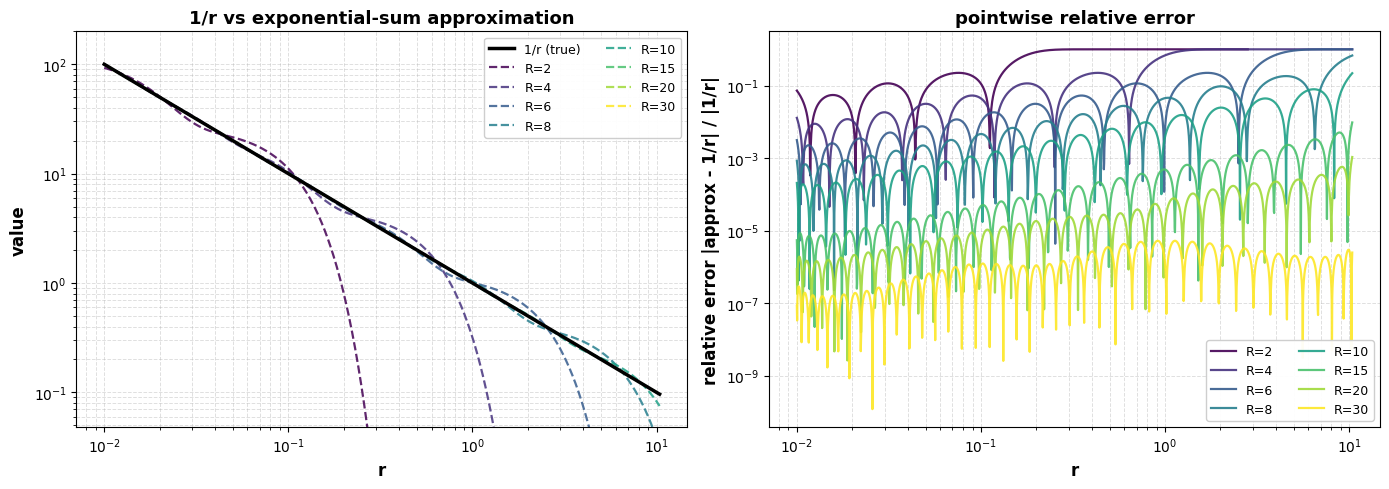

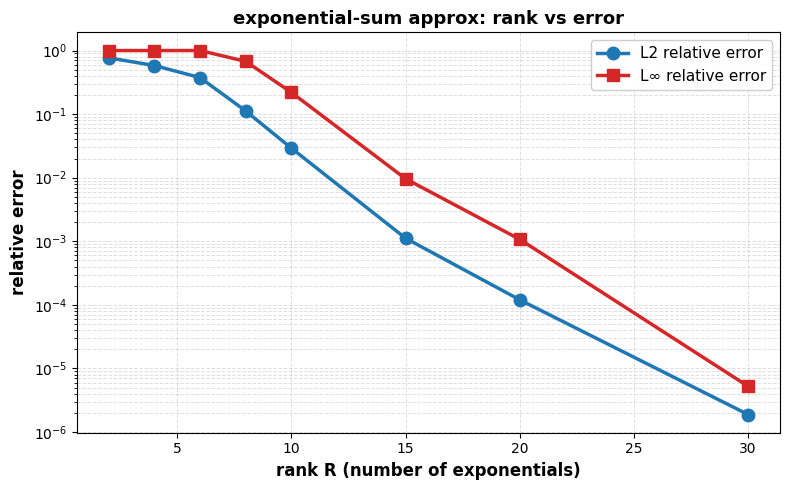

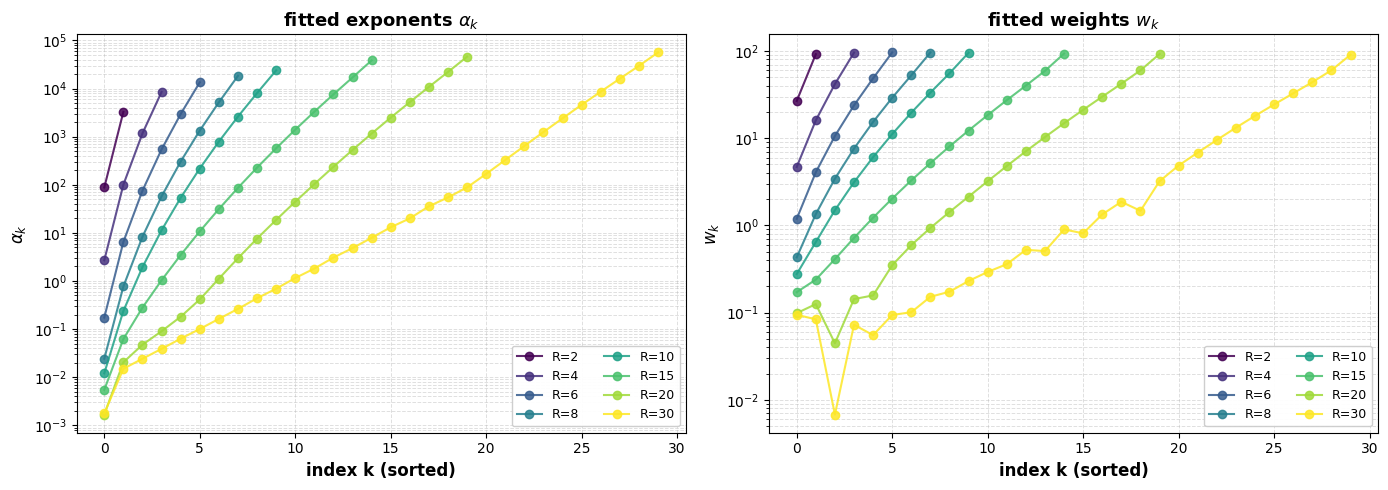

In [8]:
_UNDERFLOW_THRESHOLD = 1e-300


def _masked_loglog(ax, x, y, **kwargs):
    """y > threshold の点のみ loglog プロット（アンダーフロー除外）。"""
    valid = y > _UNDERFLOW_THRESHOLD
    if valid.any():
        ax.loglog(x[valid], y[valid], **kwargs)


def _make_colormap(n: int):
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ---------------------------------------------------------------------------
# 図1 + 図2: 近似カーブ と 点ごとの相対誤差
# ---------------------------------------------------------------------------

def plot_approximation(fits: dict, eval_grid: LogUniformGrid) -> None:
    r_eval = eval_grid.points
    f_true = 1.0 / r_eval
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.loglog(r_eval, f_true, "k-", lw=2.5, label="1/r (true)", zorder=10)

    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        _masked_loglog(ax, r_eval, approx, lw=1.6, ls="--",
                       color=color, alpha=0.85, label=f"R={r}")

    ax.set_ylim(f_true.min() * 0.5, f_true.max() * 2.0)
    ax.set_xlabel("r", fontsize=12, fontweight="bold")
    ax.set_ylabel("value", fontsize=12, fontweight="bold")
    ax.set_title("1/r vs exponential-sum approximation", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    ax2 = axes[1]
    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        valid = approx > _UNDERFLOW_THRESHOLD
        if valid.any():
            rel_err = np.abs((approx[valid] - f_true[valid]) / f_true[valid])
            ax2.loglog(r_eval[valid], rel_err, "-", lw=1.6,
                       color=color, alpha=0.9, label=f"R={r}")

    ax2.set_xlabel("r", fontsize=12, fontweight="bold")
    ax2.set_ylabel("relative error |approx - 1/r| / |1/r|",
                   fontsize=12, fontweight="bold")
    ax2.set_title("pointwise relative error", fontsize=13, fontweight="bold")
    ax2.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax2.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図3: ランク vs L2 / L∞ 誤差
# ---------------------------------------------------------------------------

def plot_rank_vs_error(fits: dict) -> None:
    ranks = sorted(fits.keys())
    l2_errs = [fits[r].l2_error for r in ranks]
    linf_errs = [fits[r].linf_error for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(ranks, l2_errs, "o-", markersize=9, lw=2.5,
                label="L2 relative error", color="C0")
    ax.semilogy(ranks, linf_errs, "s-", markersize=9, lw=2.5,
                label="L∞ relative error", color="C3")
    ax.set_xlabel("rank R (number of exponentials)", fontsize=12, fontweight="bold")
    ax.set_ylabel("relative error", fontsize=12, fontweight="bold")
    ax.set_title("exponential-sum approx: rank vs error",
                 fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, loc="best", framealpha=0.95)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図4: α_k と w_k の分布
# ---------------------------------------------------------------------------

def plot_param_distribution(fits: dict) -> None:
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for color, r in zip(colors, ranks):
        idx = np.arange(r)
        axes[0].semilogy(idx, fits[r].alphas, "o-", color=color,
                         alpha=0.85, label=f"R={r}", markersize=6)
        axes[1].semilogy(idx, np.maximum(fits[r].weights, 1e-16), "o-",
                         color=color, alpha=0.85, label=f"R={r}", markersize=6)

    for ax, ylabel, title in zip(
        axes,
        [r"$\alpha_k$", r"$w_k$"],
        [r"fitted exponents $\alpha_k$", r"fitted weights $w_k$"],
    ):
        ax.set_xlabel("index k (sorted)", fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
        ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


plot_approximation(fits, eval_grid)
plot_rank_vs_error(fits)
plot_param_distribution(fits)


In [9]:
fits[10]

ExponentialSum(weights=array([ 0.27625286,  0.6447792 ,  1.49273334,  3.12227491,  6.06387351,
       11.14314098, 19.61121249, 33.3510767 , 55.46996118, 95.47465974]), alphas=array([1.20567799e-02, 2.38407861e-01, 1.93711074e+00, 1.13082269e+01,
       5.34451329e+01, 2.17210519e+02, 7.87161570e+02, 2.60562778e+03,
       8.02999223e+03, 2.38018259e+04]), l2_error=0.02911880862170373, linf_error=0.21925389734214792)

In [10]:
V_analytic = v_analytic_gaussian(R, alpha)

In [11]:
"""
coulomb_kernel.py
=================
指数和近似 1/r ≈ Σ_k w_k exp(-α_k r²) を用いた
Hartree ポテンシャルの計算。

    V_H(r1) = ∫ ρ(r2) / |r1-r2| dr2
            ≈ Σ_k w_k ∫ ρ(r2) exp(-α_k|r1-r2|²) dr2

x,y,z の分離性を利用して各方向に 1D カーネルを順次作用させる
（mode-n product）。計算量: O(R · N³) vs 直接法 O(N⁶)。
"""

from __future__ import annotations


# ---------------------------------------------------------------------------
# 1D カーネル行列
# ---------------------------------------------------------------------------

def build_gaussian_kernel_1d(alpha: float, x: np.ndarray) -> np.ndarray:
    """K[i,j] = exp(-alpha * (x_i - x_j)²)  shape: (N, N)"""
    diff = x[:, None] - x[None, :]   # (N, N)
    return np.exp(-alpha * diff ** 2)


# ---------------------------------------------------------------------------
# 3D への作用（mode-n product）
# ---------------------------------------------------------------------------

def apply_1d_kernel_along_axis(K: np.ndarray, rho: np.ndarray, axis: int) -> np.ndarray:
    """
    3D 配列 rho の指定軸に沿って行列 K を作用させる。

    axis=0: V[i,j,k] = Σ_i' K[i,i'] ρ[i',j,k]
    axis=1: V[i,j,k] = Σ_j' K[j,j'] ρ[i,j',k]
    axis=2: V[i,j,k] = Σ_k' K[k,k'] ρ[i,j,k']
    """
    return np.moveaxis(np.tensordot(K, rho, axes=([1], [axis])), 0, axis)


def apply_separable_kernel_3d(alpha: float, x: np.ndarray, rho: np.ndarray) -> np.ndarray:
    """
    exp(-α|r1-r2|²) = exp(-α(x1-x2)²) · exp(-α(y1-y2)²) · exp(-α(z1-z2)²)
    の分離性を利用して各軸に K を順次適用する。
    """
    K = build_gaussian_kernel_1d(alpha, x)
    result = apply_1d_kernel_along_axis(K, rho, axis=0)
    result = apply_1d_kernel_along_axis(K, result, axis=1)
    result = apply_1d_kernel_along_axis(K, result, axis=2)
    return result

In [12]:
fit = fits[20]                      # 例: R=20
x_axis = xyz[0, :, 0, 0]            # 1D 座標 (N,)

V_exp = np.zeros_like(rho_grid)
for w_k, alpha_k in zip(fit.weights, fit.alphas):
    V_exp += w_k * apply_separable_kernel_3d(alpha_k, x_axis, rho_grid)
V_exp *= dx**3

err = np.linalg.norm(V_exp - V_analytic) / np.linalg.norm(V_analytic)
print(f"R={fit.rank}: V 相対誤差 = {err:.3e}")

R=20: V 相対誤差 = 7.648e-01


   R |     1/r L2 |     1/r L∞ |  V err (no corr) |   V err (corr) |       Σw_k
------------------------------------------------------------------------------
   2 |  7.671e-01 |  1.000e+00 |        8.750e-01 |      9.917e-01 |    118.583
   4 |  5.812e-01 |  1.000e+00 |        8.317e-01 |      8.922e-01 |    158.165
   6 |  3.749e-01 |  1.000e+00 |        5.631e-01 |      2.430e-01 |    184.559
   8 |  1.120e-01 |  6.750e-01 |        5.297e-01 |      5.030e-02 |    205.920
  10 |  2.912e-02 |  2.193e-01 |        5.904e-01 |      1.186e-02 |    226.650
  15 |  1.117e-03 |  9.621e-03 |        7.114e-01 |      2.951e-03 |    271.969
  20 |  1.201e-04 |  1.072e-03 |        7.648e-01 |      2.935e-03 |    291.849
  30 |  1.883e-06 |  5.245e-06 |        8.310e-01 |      2.939e-03 |    316.483


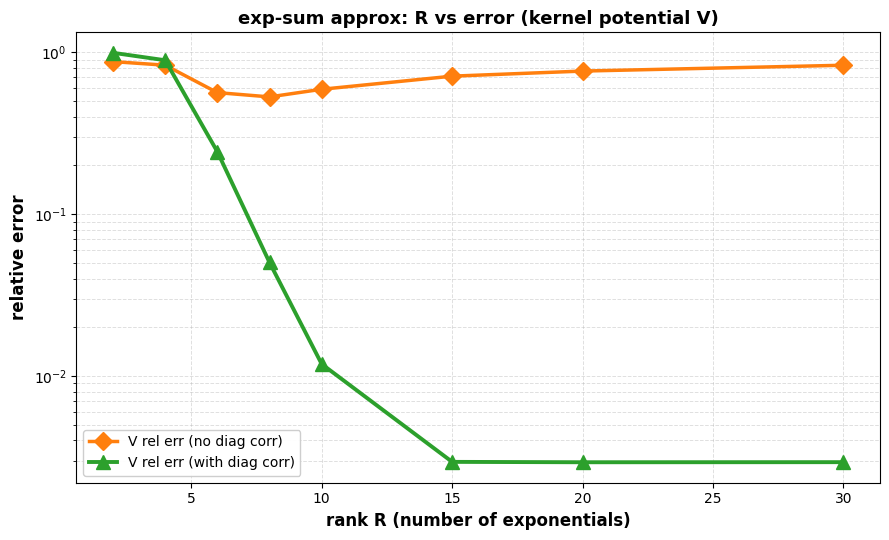

In [13]:
# ===== 各 R に対する V 相対誤差 (対角補正あり / なし) =====
x_axis = xyz[0, :, 0, 0]
cell_int_const = 2.38                    # 立方体セル ∫ 1/r d³r / dx²
K_diag_true = cell_int_const / dx

err_no_corr  = {}
err_with_corr = {}

for r, fit in fits.items():
    V_exp = np.zeros_like(rho_grid)
    for w_k, alpha_k in zip(fit.weights, fit.alphas):
        V_exp += w_k * apply_separable_kernel_3d(alpha_k, x_axis, rho_grid)

    # 補正なし
    V_no = V_exp * dx**3
    err_no_corr[r] = np.linalg.norm(V_no - V_analytic) / np.linalg.norm(V_analytic)

    V_corr = (V_exp + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
    err_with_corr[r] = np.linalg.norm(V_corr - V_analytic) / np.linalg.norm(V_analytic)

# ----- 表 -----
print(f"{'R':>4s} | {'1/r L2':>10s} | {'1/r L∞':>10s} | "
      f"{'V err (no corr)':>16s} | {'V err (corr)':>14s} | {'Σw_k':>10s}")
print("-" * 78)
for r in sorted(fits):
    print(
        f"{r:>4d} | {fits[r].l2_error:>10.3e} | {fits[r].linf_error:>10.3e} | "
        f"{err_no_corr[r]:>16.3e} | {err_with_corr[r]:>14.3e} | "
        f"{fits[r].weights.sum():>10.3f}"
    )

# ----- 図 -----
ranks_sorted = sorted(fits.keys())
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.semilogy(ranks_sorted, [err_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='V rel err (no diag corr)',     color='C1')
ax.semilogy(ranks_sorted, [err_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='V rel err (with diag corr)',  color='C2')

ax.set_xlabel('rank R (number of exponentials)', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title('exp-sum approx: R vs error (kernel potential V)',
             fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)
plt.tight_layout()
plt.show()


## 解析解との比較

CG iterations            : 39
||V_direct   - V_an|| / ||V_an|| (interior) = 2.0424e-02
||V_cg       - V_an|| / ||V_an|| (interior) = 4.6283e-03
||V_exp(R=30) - V_an|| / ||V_an|| (interior) = 3.2257e-03


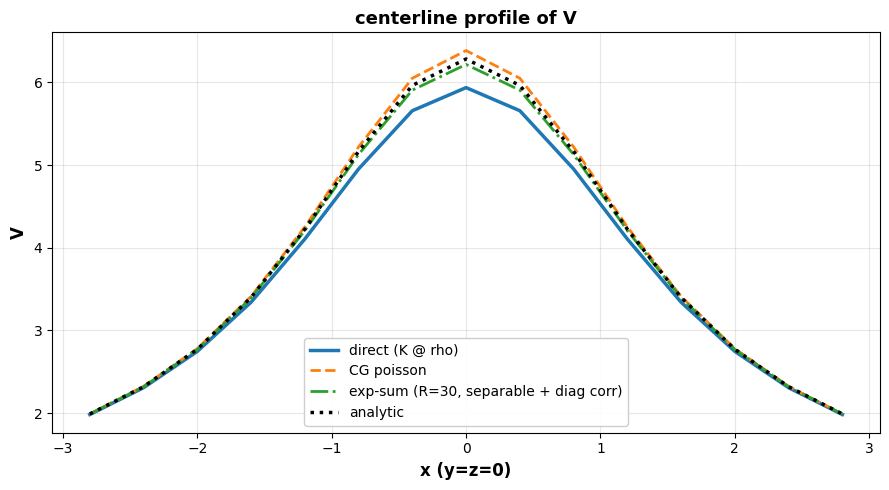

In [14]:
V_cg, residuals = poisson_solve(rho_grid, dx, tol=1e-10)

# ----- 指数和近似 + 分離可能評価 + 対角補正 -----
exp_sum_R = 30                          # 比較に使うランク
fit_es = fits[exp_sum_R]
x_axis = xyz[0, :, 0, 0]

V_exp = np.zeros_like(rho_grid)
for w_k, alpha_k in zip(fit_es.weights, fit_es.alphas):
    V_exp += w_k * apply_separable_kernel_3d(alpha_k, x_axis, rho_grid)
V_exp += (K_diag_true - fit_es.weights.sum()) * rho_grid    # 対角補正
V_exp *= dx**3

# ----- 各手法 vs 解析解 -----
print(f"CG iterations            : {len(residuals)}")
print(f"||V_direct   - V_an|| / ||V_an|| (interior) = {l2_error(V_grid, V_analytic, dx):.4e}")
print(f"||V_cg       - V_an|| / ||V_an|| (interior) = {l2_error(V_cg,   V_analytic, dx):.4e}")
print(f"||V_exp(R={exp_sum_R}) - V_an|| / ||V_an|| (interior) = {l2_error(V_exp,  V_analytic, dx):.4e}")

m = N // 2
xs = xyz[0, :, m, m]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, V_grid[:, m, m],     '-',  lw=2.5, label='direct (K @ rho)',          color='C0')
ax.plot(xs, V_cg[:, m, m],       '--', lw=2.0, label='CG poisson',                color='C1')
ax.plot(xs, V_exp[:, m, m],      '-.', lw=2.0,
        label=f'exp-sum (R={exp_sum_R}, separable + diag corr)', color='C2')
ax.plot(xs, V_analytic[:, m, m], ':',  lw=2.5, label='analytic',                  color='k')
ax.set_xlabel('x (y=z=0)', fontsize=12, fontweight='bold')
ax.set_ylabel('V', fontsize=12, fontweight='bold')
ax.set_title('centerline profile of V', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='best', framealpha=0.95)
plt.tight_layout()
plt.show()
